## Recommender Systems

Group 14: Suvaion Das and Amanda Dahm

In [5]:
import scipy 
import numpy
import surprise

data = Dataset.load_builtin('ml-100k')


SVD

In [3]:
from surprise import SVD
from surprise import Dataset
from surprise.model_selection import cross_validate

data = Dataset.load_builtin('ml-100k')

svd_algo = SVD(n_epochs=30, n_factors=50)

cross_validate(svd_algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9392  0.9393  0.9386  0.9396  0.9414  0.9396  0.0009  
MAE (testset)     0.7364  0.7369  0.7390  0.7374  0.7394  0.7378  0.0012  
Fit time          2.20    2.31    2.59    2.54    2.27    2.38    0.15    
Test time         0.20    0.31    0.46    0.23    0.23    0.29    0.09    


{'test_rmse': array([0.93917725, 0.93925726, 0.93862642, 0.93955853, 0.94137003]),
 'test_mae': array([0.73639777, 0.73685111, 0.73895482, 0.73737444, 0.73943031]),
 'fit_time': (2.2044119834899902,
  2.3123385906219482,
  2.591719627380371,
  2.537552833557129,
  2.2653322219848633),
 'test_time': (0.2009875774383545,
  0.30852174758911133,
  0.4555778503417969,
  0.23371315002441406,
  0.2345142364501953)}

In [5]:
n_factors = [1, 50, 100, 200]
n_epochs = [20, 30]
lr_all = [.05, .005, .0005]
reg_all = [.02, .08, .002]

for factor in n_factors:
  for epoch in n_epochs:
    print("\nFactors = %d, Epochs = %d" %(factor, epoch))
    svd_algo_custom = SVD(n_epochs=epoch,
                          n_factors=factor)
    cross_validate(svd_algo_custom, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

Factors = 1, Epochs = 20
Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9367  0.9421  0.9396  0.9432  0.9389  0.9401  0.0023  
MAE (testset)     0.7402  0.7416  0.7437  0.7459  0.7408  0.7424  0.0021  
Fit time          1.05    0.87    0.89    0.96    0.82    0.92    0.08    
Test time         0.17    0.26    0.17    0.28    0.24    0.22    0.05    
Factors = 1, Epochs = 30
Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9465  0.9352  0.9460  0.9265  0.9347  0.9378  0.0076  
MAE (testset)     0.7490  0.7375  0.7470  0.7290  0.7374  0.7400  0.0073  
Fit time          1.25    1.35    1.40    1.34    1.23    1.31    0.07    
Test time         0.16    0.28    0.18    0.30    0.16    0.22    0.06    
Factors = 50, Epochs = 20
Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

            

In [ ]:
# SVD Final parameters

from surprise import SVD
from surprise import Dataset
from surprise.model_selection import cross_validate

svd_algo_final = SVD(n_epochs=epoch,
                      n_factors=factor)
cross_validate(svd_algo_final, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

kNN

In [6]:
from surprise import KNNWithMeans
from surprise import Dataset
from surprise.model_selection import cross_validate

data = Dataset.load_builtin('ml-100k')

knn_algo = KNNWithMeans()

cross_validate(knn_algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Evaluating RMSE, MAE of algorithm KNNWithMeans on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9441  0.9509  0.9561  0.9531  0.9490  0.9506  0.0040  
MAE (testset)     0.7446  0.7474  0.7556  0.7492  0.7489  0.7491  0.0036  
Fit time          0.56    0.53    0.54    0.57    0.56    0.55    0.01    
Test time         4.90    4.86    4.76    4.90    4.77    4.84    0.06    


{'test_rmse': array([0.94408429, 0.95094281, 0.95611341, 0.95307855, 0.94897084]),
 'test_mae': array([0.74457517, 0.74736882, 0.75561131, 0.74916384, 0.74893239]),
 'fit_time': (0.5563702583312988,
  0.5348672866821289,
  0.5382695198059082,
  0.5672206878662109,
  0.557098388671875),
 'test_time': (4.90304970741272,
  4.8633131980896,
  4.764704942703247,
  4.898573398590088,
  4.7717506885528564)}

In [12]:
ks = [20, 40, 60, 100]
min_k = [1, 2 ,3]
sim_options =  [ {'name': 'cosine'}, {'name': 'msd'}, {'name':'pearson'}]


for k in ks:
  for min in min_k:
    for option in sim_options:
      print("k = %d, min_k = %d, sim_options = %s" %(k, min, option))
      knn_algo_custom = KNNWithMeans(k=k, min_k=min, sim_options=option, verbose=False)
      cross_validate(knn_algo_custom, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

k = 20, min_k = 1, sim_options = {'name': 'cosine'}
Evaluating RMSE, MAE of algorithm KNNWithMeans on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9567  0.9673  0.9637  0.9664  0.9666  0.9641  0.0039  
MAE (testset)     0.7566  0.7645  0.7608  0.7668  0.7658  0.7629  0.0038  
Fit time          0.74    0.78    0.78    0.74    0.85    0.78    0.04    
Test time         4.33    4.25    3.93    4.33    3.95    4.16    0.18    
k = 20, min_k = 1, sim_options = {'name': 'msd'}
Evaluating RMSE, MAE of algorithm KNNWithMeans on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9643  0.9596  0.9600  0.9526  0.9500  0.9573  0.0052  
MAE (testset)     0.7599  0.7577  0.7563  0.7528  0.7494  0.7552  0.0037  
Fit time          0.53    0.59    0.58    0.65    0.53    0.58    0.04    
Test time         4.09    4.19    4.44    4.62    4.03    4.27    0.22    
k = 20, min_k = 1, sim_

In [8]:
# kNN Final Parameters
from surprise import KNNWithMeans
from surprise import Dataset
from surprise.model_selection import cross_validate

#TODO fill in final params when determined above
knn_algo_final = KNNWithMeans(k=k, min_k=min, sim_options=option, verbose=False)
cross_validate(knn_algo_final, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

NameError: name 'k' is not defined

Random

In [4]:
from surprise import NormalPredictor
from surprise import Dataset
from surprise.model_selection import cross_validate

data = Dataset.load_builtin('ml-100k')

random_algo = NormalPredictor()

cross_validate(random_algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

Evaluating RMSE, MAE of algorithm NormalPredictor on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    1.5209  1.5186  1.5243  1.5204  1.5226  1.5214  0.0020  
MAE (testset)     1.2219  1.2190  1.2236  1.2227  1.2225  1.2219  0.0016  
Fit time          0.16    0.17    0.18    0.17    0.16    0.17    0.01    
Test time         0.12    0.22    0.21    0.19    0.11    0.17    0.04    


{'test_rmse': array([1.52088545, 1.51857563, 1.52429583, 1.52041937, 1.52262473]),
 'test_mae': array([1.2219375 , 1.21896685, 1.22363214, 1.22270142, 1.22247072]),
 'fit_time': (0.1555919647216797,
  0.17183327674865723,
  0.17997431755065918,
  0.16799259185791016,
  0.16469860076904297),
 'test_time': (0.12459087371826172,
  0.21639370918273926,
  0.20798349380493164,
  0.19447898864746094,
  0.11429023742675781)}

In [6]:
# Random final parameters, unchanged

Matrix factorization with regularization

In [9]:
from surprise import NMF
from surprise import Dataset
from surprise.model_selection import cross_validate

data = Dataset.load_builtin('ml-100k')

nmf_algo = NMF()

cross_validate(nmf_algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

Evaluating RMSE, MAE of algorithm NMF on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9709  0.9564  0.9547  0.9648  0.9662  0.9626  0.0061  
MAE (testset)     0.7603  0.7519  0.7532  0.7580  0.7604  0.7568  0.0036  
Fit time          3.29    2.92    3.17    3.28    3.63    3.26    0.23    
Test time         0.14    0.22    0.14    0.31    0.37    0.24    0.09    


{'test_rmse': array([0.97088193, 0.956376  , 0.95468064, 0.96479189, 0.96622536]),
 'test_mae': array([0.76033772, 0.75186635, 0.75322738, 0.75799595, 0.7604068 ]),
 'fit_time': (3.287118911743164,
  2.9166626930236816,
  3.1695241928100586,
  3.283564567565918,
  3.6289358139038086),
 'test_time': (0.14397239685058594,
  0.22083830833435059,
  0.14301061630249023,
  0.3085181713104248,
  0.36832642555236816)}

In [11]:
from surprise import NMF
from surprise import Dataset
from surprise.model_selection import cross_validate

n_factors = [1, 50, 100, 200]
n_epochs = [20, 30]
biased = [False, True]

for factor in n_factors:
  for epoch in n_epochs:
    for tf in biased:
      print("Factors = %d, Epochs = %d, Biased = %s" %(factor, epoch, tf))
      nmf_algo_custom = NMF(n_factors=factor, n_epochs=epoch, biased=tf)
      cross_validate(nmf_algo_custom, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

Factors = 1, Epochs = 20, Biased = [False, True]
Evaluating RMSE, MAE of algorithm NMF on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    2.1932  2.1807  2.2099  2.1834  2.1783  2.1891  0.0116  
MAE (testset)     1.9851  1.9700  1.9998  1.9754  1.9670  1.9795  0.0119  
Fit time          1.17    0.99    1.07    1.09    0.95    1.05    0.08    
Test time         0.37    0.13    0.33    0.22    0.24    0.26    0.09    
Factors = 1, Epochs = 20, Biased = [False, True]
Evaluating RMSE, MAE of algorithm NMF on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9500  0.9450  0.9309  0.9466  0.9327  0.9411  0.0077  
MAE (testset)     0.7519  0.7477  0.7354  0.7453  0.7375  0.7436  0.0062  
Fit time          0.95    1.04    1.02    1.00    1.12    1.03    0.06    
Test time         0.17    0.29    0.18    0.36    0.18    0.24    0.07    
Factors = 1, Epochs = 30, Biased = [False, T

In [7]:
# NMF Final Parameters

from surprise import NMF
from surprise import Dataset
from surprise.model_selection import cross_validate

nmf_algo_final = NMF(n_factors=1, n_epochs=20, biased=True)
cross_validate(nmf_algo_final, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

Evaluating RMSE, MAE of algorithm NMF on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9366  0.9424  0.9390  0.9337  0.9481  0.9400  0.0050  
MAE (testset)     0.7393  0.7464  0.7418  0.7364  0.7495  0.7427  0.0047  
Fit time          1.02    1.08    0.81    0.74    0.85    0.90    0.13    
Test time         0.32    0.15    0.15    0.26    0.14    0.21    0.07    


{'test_rmse': array([0.936591  , 0.94235833, 0.93904036, 0.93369585, 0.94809688]),
 'test_mae': array([0.73927612, 0.74639719, 0.74183772, 0.73636578, 0.74945184]),
 'fit_time': (1.0215351581573486,
  1.0819177627563477,
  0.8091518878936768,
  0.7395265102386475,
  0.849895715713501),
 'test_time': (0.31522464752197266,
  0.15466666221618652,
  0.150604248046875,
  0.26130080223083496,
  0.14392733573913574)}

Deep Neural Network

In [78]:
import io
import os
import math
import copy
import pickle
import zipfile
from textwrap import wrap
from pathlib import Path
from itertools import zip_longest
from collections import defaultdict
from urllib.error import URLError
from urllib.request import urlopen
import pprint

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
from torch import nn
from torch import optim
from torch.nn import functional as F 
from torch.optim.lr_scheduler import _LRScheduler

plt.style.use('ggplot')

def set_random_seed(state=1):
    gens = (np.random.seed, torch.manual_seed, torch.cuda.manual_seed)
    for set_state in gens:
        set_state(state)

RANDOM_STATE = 1
set_random_seed(RANDOM_STATE)



In [79]:
def try_download(url, download_path):
    archive_name = url.split('/')[-1]
    folder_name, _ = os.path.splitext(archive_name)
    
    try:
        r = urlopen(url)
    except URLError as e:
        print('Cannot download the data. Error: %s' % s)
        return 

    assert r.status == 200
    data = r.read()

    with zipfile.ZipFile(io.BytesIO(data)) as arch:
        arch.extractall(download_path)
        
    print('The archive is extracted into folder: %s' % download_path)
def read_data(path):
    files = {}
    for filename in path.glob('*'):
        if filename.suffix == '.csv':
            files[filename.stem] = pd.read_csv(filename)
        elif filename.suffix == '.data':
            if filename.stem == 'u':
                columns = ['userId', 'movieId', 'rating', 'timestamp']
            else:
                columns = ['movieId', 'title', 'genres']
            data = pd.read_csv(filename, sep='\t', names=columns, engine='python')
            files["u.data"] = data
        elif filename.suffix == '.item':
            columns = ['movieId', 
                        'movie title' ,
                        'release date' ,
                        'video release date',
                        'IMDb URL',
                        'unknown',
                        'Action',
                        'Adventure',
                        'Animation',
                        'Childrens',
                        'Comedy',
                        'Crime',
                        'Documentary',
                        'Drama',
                        'Fantasy',
                        'Film-Noir' ,
                        'Horror',
                        'Musical',
                        'Mystery',
                        'Romance',
                        'Sci-Fi',
                        'Thriller' ,
                        'War',
                        'Western']
            data = pd.read_csv(filename, sep='|', names=columns, index_col=False, engine='python', encoding="ISO-8859-1")
            files['u.item'] = data
    return files['u.data'], files['u.item']




# pick any other dataset instead
archive_url = f'http://files.grouplens.org/datasets/movielens/ml-100k.zip'
download_path = Path.home() / 'Documents' / 'Academics' / '435 Data Mining'/ 'proj3_435' 

try_download(archive_url, download_path)

# pick one of the available folders
ratings, movies = read_data(download_path / 'ml-100k')

The archive is extracted into folder: /home/demlenar/Documents/Academics/435 Data Mining/proj3_435


In [116]:
class EmbeddingNet(nn.Module):
    """
    Creates a dense network with embedding layers.
    
    Args:
    
        n_users:            
            Number of unique users in the dataset.
        n_movies: 
            Number of unique movies in the dataset.
        n_factors: 
            Number of columns in the embeddings matrix.
        embedding_dropout: 
            Dropout rate to apply right after embeddings layer.
        hidden:
            A single integer or a list of integers defining the number of 
            units in hidden layer(s).
        dropouts: 
            A single integer or a list of integers defining the dropout 
            layers rates applyied right after each of hidden layers.
            
    """
    def __init__(self, n_users, n_movies,
                 n_factors=50, embedding_dropout=0.02, 
                 hidden=10, dropouts=0.2):
        
        super().__init__()
        hidden = get_list(hidden)
        dropouts = get_list(dropouts)
        n_last = hidden[-1]
        
        def gen_layers(n_in):
            nonlocal hidden, dropouts
            assert len(dropouts) <= len(hidden)
            
            for n_out, rate in zip_longest(hidden, dropouts):
                yield nn.Linear(n_in, n_out)
                yield nn.ReLU()
                if rate is not None and rate > 0.:
                    yield nn.Dropout(rate)
                n_in = n_out
            
        print("n_users ", n_users)
        print("n_factors", n_factors)
        print("n_movies", n_movies)
        self.u = nn.Embedding(n_users, n_factors)
        self.m = nn.Embedding(n_movies, n_factors)
        print("backstop")
        self.drop = nn.Dropout(embedding_dropout)
        self.hidden = nn.Sequential(*list(gen_layers(n_factors * 2)))
        self.fc = nn.Linear(n_last, 1)
        self._init()
        
    def forward(self, users, movies, minmax=None):
        print("users and movies in forward: ", users, movies)
        features = torch.cat([self.u(users), self.m(movies)], dim=1)
        x = self.drop(features)
        x = self.hidden(x)
        out = torch.sigmoid(self.fc(x))
        if minmax is not None:
            min_rating, max_rating = minmax
            out = out*(max_rating - min_rating + 1) + min_rating - 0.5
        return out
    
    def _init(self):
        
        def init(m):
            if type(m) == nn.Linear:
                torch.nn.init.xavier_uniform_(m.weight)
                m.bias.data.fill_(0.01)
                
        self.u.weight.data.uniform_(-0.05, 0.05)
        self.m.weight.data.uniform_(-0.05, 0.05)
        self.hidden.apply(init)
        init(self.fc)
    
    
def get_list(n):
    if isinstance(n, (int, float)):
        return [n]
    elif hasattr(n, '__iter__'):
        return list(n)
    raise TypeError('layers configuraiton should be a single number or a list of numbers')
    


In [97]:
def create_dataset(ratings, top=None):
    if top is not None:
        ratings.groupby('userId')['rating'].count()
    
    unique_users = ratings.userId.unique()
    user_to_index = {old: new for new, old in enumerate(unique_users)}
    new_users = ratings.userId.map(user_to_index)
    
    unique_movies = ratings.movieId.unique()
    movie_to_index = {old: new for new, old in enumerate(unique_movies)}
    new_movies = ratings.movieId.map(movie_to_index)
    
    n_users = unique_users.shape[0]
    n_movies = unique_movies.shape[0]
    
    X = pd.DataFrame({'user_id': new_users, 'movie_id': new_movies})
    y = ratings['rating'].astype(np.float32)
    return (n_users, n_movies), (X, y), (user_to_index, movie_to_index)


(n, m), (X, y), _ = create_dataset(ratings)
print(f'Embeddings: {n} users, {m} movies')
print(f'Dataset shape: {X.shape}')
print(f'Target shape: {y.shape}')




Embeddings: 943 users, 1682 movies
Dataset shape: (100000, 2)
Target shape: (100000,)


In [98]:
class ReviewsIterator:
    
    def __init__(self, X, y, batch_size=32, shuffle=True):
        X, y = np.asarray(X), np.asarray(y)
        
        if shuffle:
            index = np.random.permutation(X.shape[0])
            X, y = X[index], y[index]
            
        self.X = X
        self.y = y
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.n_batches = int(math.ceil(X.shape[0] // batch_size))
        self._current = 0
        
    def __iter__(self):
        return self
    
    def __next__(self):
        return self.next()
    
    def next(self):
        if self._current >= self.n_batches:
            raise StopIteration()
        k = self._current
        self._current += 1
        bs = self.batch_size
        return self.X[k*bs:(k + 1)*bs], self.y[k*bs:(k + 1)*bs]

def batches(X, y, bs=32, shuffle=True):
    for xb, yb in ReviewsIterator(X, y, bs, shuffle):
        xb = torch.LongTensor(xb)
        yb = torch.FloatTensor(yb)
        yield xb, yb.view(-1, 1) 

for x_batch, y_batch in batches(X, y, bs=4):
    print(x_batch)
    print(y_batch)
    break

tensor([[ 41, 239],
        [118, 730],
        [187,  77],
        [499, 471]])
tensor([[3.],
        [4.],
        [4.],
        [4.]])


In [77]:
# EmbeddingNet(n, m, n_factors=150, hidden=100, dropouts=0.5)

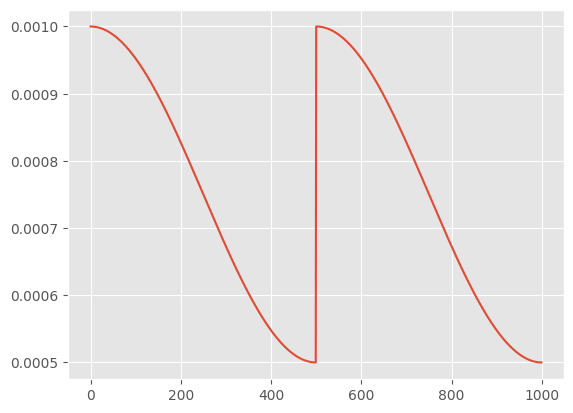

In [99]:
class CyclicLR(_LRScheduler):
    
    def __init__(self, optimizer, schedule, last_epoch=-1):
        assert callable(schedule)
        self.schedule = schedule
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        return [self.schedule(self.last_epoch, lr) for lr in self.base_lrs]

def triangular(step_size, max_lr, method='triangular', gamma=0.99):
    
    def scheduler(epoch, base_lr):
        period = 2 * step_size
        cycle = math.floor(1 + epoch/period)
        x = abs(epoch/step_size - 2*cycle + 1)
        delta = (max_lr - base_lr)*max(0, (1 - x))

        if method == 'triangular':
            pass  # we've already done
        elif method == 'triangular2':
            delta /= float(2 ** (cycle - 1))
        elif method == 'exp_range':
            delta *= (gamma**epoch)
        else:
            raise ValueError('unexpected method: %s' % method)
            
        return base_lr + delta
        
    return scheduler

def cosine(t_max, eta_min=0):
    
    def scheduler(epoch, base_lr):
        t = epoch % t_max
        return eta_min + (base_lr - eta_min)*(1 + math.cos(math.pi*t/t_max))/2
    
    return scheduler

def plot_lr(schedule):
    ts = list(range(1000))
    y = [schedule(t, 0.001) for t in ts]
    plt.plot(ts, y)

plot_lr(cosine(t_max=500, eta_min=0.0005))




In [86]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
datasets = {'train': (X_train, y_train), 'val': (X_valid, y_valid)}
dataset_sizes = {'train': len(X_train), 'val': len(X_valid)}

In [101]:
minmax = ratings.rating.min().astype(float), ratings.rating.max().astype(float)
minmax


net = EmbeddingNet(
    n_users=n, n_movies=m, 
    n_factors=50, hidden=[200, 200, 200], 
    embedding_dropout=0.05, dropouts=[0.5, 0.5, 0.25])

n_users  943
n_factors 50
n_movies 1682
backstop


In [120]:
lr = 1e-3
wd = 1e-5
bs = 2000
n_epochs = 100
patience = 10
no_improvements = 0
best_loss = np.inf
best_weights = None
history = []
lr_history = []

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

net.to(device)
criterion = nn.MSELoss(reduction='sum')
optimizer = optim.Adam(net.parameters(), lr=lr, weight_decay=wd)
iterations_per_epoch = int(math.ceil(dataset_sizes['train'] // bs))
scheduler = CyclicLR(optimizer, cosine(t_max=iterations_per_epoch * 2, eta_min=lr/10))

for epoch in range(n_epochs):
    stats = {'epoch': epoch + 1, 'total': n_epochs}
    
    for phase in ('train', 'val'):
        training = phase == 'train'
        running_loss = 0.0
        n_batches = 0
        
        for batch in batches(*datasets[phase], shuffle=training, bs=bs):
            x_batch, y_batch = [b.to(device) for b in batch]
            optimizer.zero_grad()
        
            # compute gradients only during 'train' phase
            with torch.set_grad_enabled(training):
                # print("test: ", len(x_batch[:, 1]), len(x_batch[:, 0]), len(batch), minmax)
                outputs = net(x_batch[:, 1], x_batch[:, 0], minmax)
                loss = criterion(outputs, y_batch)
                
                # don't update weights and rates when in 'val' phase
                if training:
                    scheduler.step()
                    loss.backward()
                    optimizer.step()
                    lr_history.extend(scheduler.get_lr())
                    
            running_loss += loss.item()
            
        epoch_loss = running_loss / dataset_sizes[phase]
        stats[phase] = epoch_loss
        
        # early stopping: save weights of the best model so far
        if phase == 'val':
            if epoch_loss < best_loss:
                print('loss improvement on epoch: %d' % (epoch + 1))
                best_loss = epoch_loss
                best_weights = copy.deepcopy(net.state_dict())
                no_improvements = 0
            else:
                no_improvements += 1
                
    history.append(stats)
    print('[{epoch:03d}/{total:03d}] train: {train:.4f} - val: {val:.4f}'.format(**stats))
    if no_improvements >= patience:
        print('early stopping after epoch {epoch:03d}'.format(**stats))
        break

IndexError: index out of range in self